### 0. Read the data after cleaning based on mutual information.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from feature_importance_sorter import FeatureImportanceSorter

DATA_DIR = Path('..') / 'data'
N_RUNS = 200

X_train = pd.read_csv(DATA_DIR / 'x_train_scaled_reduced_after_mi.csv')
y_train = np.loadtxt(DATA_DIR / 'y_train.txt', skiprows=1).astype(int)

feature_names = X_train.columns.tolist()
X = X_train.to_numpy()

print(f'X_train: {X_train.shape}   features: {len(feature_names)}')
print(f'y_train: {y_train.shape}   positive rate: {y_train.mean():.3f}')
print(f'Default runs per model: {N_RUNS}')

X_train: (5000, 493)   features: 493
y_train: (5000,)   positive rate: 0.498
Default runs per model: 200


In [2]:
MODEL_LABELS = {
    'rf': 'Random Forest',
    'extra': 'ExtraTrees',
    'lgbm': 'LightGBM',
    'xgb': 'XGBoost',
}


def run_model_study(
    model_type: str,
    n_runs: int = N_RUNS,
    top_n: int = 25,
    n_splits: int = 5,
):
    """Run CV importance study, save CSVs, print summary tables, and plot top features."""
    if model_type not in MODEL_LABELS:
        raise ValueError(
            f"Unknown model_type '{model_type}'. Choose from: {list(MODEL_LABELS)}"
        )

    label = MODEL_LABELS[model_type]
    print(f'=== {label} ({model_type}) — {n_runs} runs, {n_splits}-fold CV ===')

    score_rows = []
    importance_rows = []
    log_every = 1

    for run in range(n_runs):
        sorter = FeatureImportanceSorter(random_seed=run)
        ranking, summary, params = sorter.get_ranking(
            X,
            y_train,
            feature_names=feature_names,
            model_type=model_type,
            random_config=(run > 0),
            n_splits=n_splits,
        )

        score_row = {
            'run_id': run,
            'random_seed': summary['random_seed'],
            'model_type': summary['model_type'],
            'config_type': summary['config_type'],
        }
        for metric in ('acc', 'prec', 'rec', 'f1', 'tp', 'fp'):
            score_row[f'{metric}_mean'] = summary[metric]['mean']
            score_row[f'{metric}_std'] = summary[metric]['std']
        for key, value in params.items():
            score_row[f'param_{key}'] = value
        score_rows.append(score_row)

        run_importance = ranking[['feature_name', 'importance']].copy()
        run_importance.insert(0, 'run_id', run)
        importance_rows.append(run_importance)

        if (run + 1) % log_every == 0 or (run + 1) == n_runs:
            print(f'Completed {run + 1}/{n_runs} runs')

    scores_df = pd.DataFrame(score_rows)
    importance_long_df = pd.concat(importance_rows, ignore_index=True)

    importance_summary = (
        importance_long_df
        .groupby('feature_name', as_index=False)
        .agg(
            importance_mean=('importance', 'mean'),
            importance_std=('importance', 'std'),
        )
        .sort_values('importance_mean', ascending=False)
        .reset_index(drop=True)
    )
    importance_summary['rank'] = np.arange(1, len(importance_summary) + 1)

    out_dir = DATA_DIR / f'{model_type}_feature_importance'
    out_dir.mkdir(parents=True, exist_ok=True)

    scores_path = out_dir / f'{model_type}_model_scores_mi_reduced.csv'
    importance_path = out_dir / f'{model_type}_model_feature_importance_mi_reduced.csv'

    scores_df.to_csv(scores_path, index=False)
    importance_long_df.to_csv(importance_path, index=False)

    print(f'Saved scores:     {scores_path}  ({len(scores_df)} runs)')
    print(f'Saved importance: {importance_path}  ({len(importance_long_df)} rows)')
    print(f'Scores shape: {scores_df.shape}, importance shape: {importance_long_df.shape}')

    print('\nRun scores (first 5):')
    display(scores_df.head())

    print('\nTop 20 features by mean importance:')
    display(importance_summary.head(20))

    plot_df = importance_summary.head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 10))
    ax.barh(
        plot_df['feature_name'],
        plot_df['importance_mean'],
        xerr=plot_df['importance_std'],
        color='#4e79a7',
        ecolor='#333333',
        capsize=2,
    )
    ax.set_xlabel(f'Mean feature importance ({n_runs} {label} runs, {n_splits}-fold CV each)')
    ax.set_title(f'Top {top_n} features — {label} — MI-reduced dataset')
    plt.tight_layout()
    plt.show()

    return scores_df, importance_long_df, importance_summary

The first run is the default model provided by the model's package.

### 1. Assess the feature importances using different configurations of Random Forest

=== Random Forest (rf) — 200 runs, 5-fold CV ===
Completed 1/200 runs
Completed 2/200 runs
Completed 3/200 runs
Completed 4/200 runs
Completed 5/200 runs
Completed 6/200 runs
Completed 7/200 runs
Completed 8/200 runs
Completed 9/200 runs
Completed 10/200 runs
Completed 11/200 runs
Completed 12/200 runs
Completed 13/200 runs
Completed 14/200 runs
Completed 15/200 runs
Completed 16/200 runs
Completed 17/200 runs
Completed 18/200 runs
Completed 19/200 runs
Completed 20/200 runs
Completed 21/200 runs
Completed 22/200 runs
Completed 23/200 runs
Completed 24/200 runs
Completed 25/200 runs
Completed 26/200 runs
Completed 27/200 runs
Completed 28/200 runs
Completed 29/200 runs
Completed 30/200 runs
Completed 31/200 runs
Completed 32/200 runs
Completed 33/200 runs
Completed 34/200 runs
Completed 35/200 runs
Completed 36/200 runs
Completed 37/200 runs
Completed 38/200 runs
Completed 39/200 runs
Completed 40/200 runs
Completed 41/200 runs
Completed 42/200 runs
Completed 43/200 runs
Completed 44/2

,run_id,random_seed,model_type,config_type,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,...,tp_mean,tp_std,fp_mean,fp_std,param_n_estimators,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_criterion,param_class_weight
0,0,0,rf,default,0.6182,0.008447,0.627817,0.012390,0.572742,0.006969,...,285.0,3.741657,169.2,10.495713,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,rf,random,0.6246,0.014705,0.652779,0.016418,0.524124,0.021045,...,260.8,10.380751,138.6,5.238320,87.0,6.0,4.0,6.0,gini,None
2,2,2,rf,random,0.6312,0.025451,0.656718,0.025973,0.540624,0.039283,...,269.0,19.339080,140.2,8.328265,218.0,4.0,4.0,7.0,gini,balanced
3,3,3,rf,random,0.6366,0.017212,0.669291,0.020999,0.532945,0.020561,...,265.2,10.400000,131.0,8.294577,412.0,7.0,1.0,3.0,gini,None
4,4,4,rf,random,0.6400,0.019759,0.666857,0.023909,0.553065,0.025676,...,275.2,12.671227,137.6,12.224565,172.0,7.0,3.0,9.0,entropy,balanced



Top 20 features by mean importance:


,feature_name,importance_mean,importance_std,rank
0,V176,0.022652,0.007609,1
1,V191,0.021992,0.007658,2
2,V255,0.021787,0.006997,3
3,V160,0.018447,0.006071,4
4,V224,0.015395,0.006682,5
5,V215,0.014273,0.004171,6
6,V380,0.014108,0.004408,7
7,V342,0.013829,0.003865,8
8,V483,0.013508,0.004101,9
9,V11,0.013077,0.005943,10


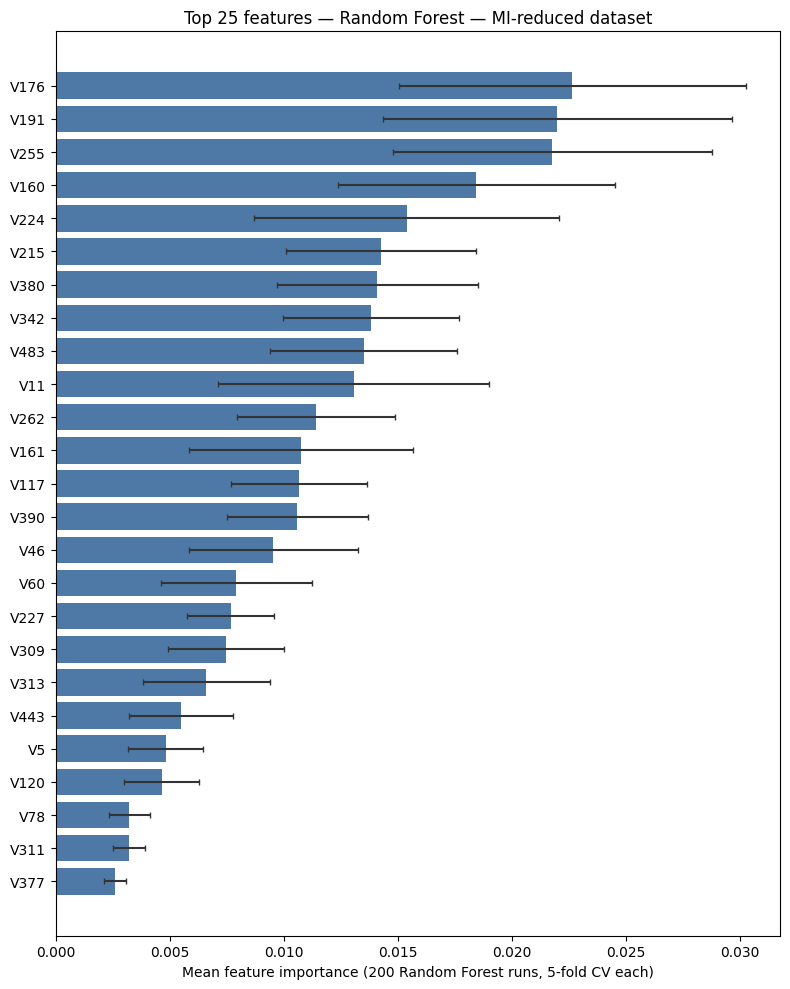

In [3]:
rf_scores, rf_importance_long, rf_summary = run_model_study('rf', N_RUNS)

### 2. Assess the feature importances using different configurations of ExtraTrees

=== ExtraTrees (extra) — 200 runs, 5-fold CV ===
Completed 1/200 runs
Completed 2/200 runs
Completed 3/200 runs
Completed 4/200 runs
Completed 5/200 runs
Completed 6/200 runs
Completed 7/200 runs
Completed 8/200 runs
Completed 9/200 runs
Completed 10/200 runs
Completed 11/200 runs
Completed 12/200 runs
Completed 13/200 runs
Completed 14/200 runs
Completed 15/200 runs
Completed 16/200 runs
Completed 17/200 runs
Completed 18/200 runs
Completed 19/200 runs
Completed 20/200 runs
Completed 21/200 runs
Completed 22/200 runs
Completed 23/200 runs
Completed 24/200 runs
Completed 25/200 runs
Completed 26/200 runs
Completed 27/200 runs
Completed 28/200 runs
Completed 29/200 runs
Completed 30/200 runs
Completed 31/200 runs
Completed 32/200 runs
Completed 33/200 runs
Completed 34/200 runs
Completed 35/200 runs
Completed 36/200 runs
Completed 37/200 runs
Completed 38/200 runs
Completed 39/200 runs
Completed 40/200 runs
Completed 41/200 runs
Completed 42/200 runs
Completed 43/200 runs
Completed 44/2

,run_id,random_seed,model_type,config_type,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,...,tp_mean,tp_std,fp_mean,fp_std,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_criterion,param_class_weight
0,0,0,extra,default,0.5624,0.009351,0.568943,0.010324,0.497586,0.020719,...,247.6,10.346014,187.6,8.731552,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,extra,random,0.5950,0.013327,0.626703,0.015828,0.459829,0.024672,...,228.8,12.073111,136.2,7.110556,87.0,4.0,5.0,9.0,gini,None
2,2,2,extra,random,0.6066,0.013836,0.615165,0.015144,0.559499,0.018017,...,278.4,8.754427,174.2,8.471127,218.0,NaN,9.0,9.0,gini,balanced
3,3,3,extra,random,0.6172,0.026671,0.662062,0.038829,0.471436,0.028673,...,234.6,14.485855,119.8,14.302447,412.0,5.0,2.0,4.0,gini,None
4,4,4,extra,random,0.6148,0.013775,0.638161,0.014119,0.520912,0.022355,...,259.2,10.998182,146.8,3.544009,172.0,5.0,8.0,8.0,entropy,balanced



Top 20 features by mean importance:


,feature_name,importance_mean,importance_std,rank
0,V176,0.017028,0.008895,1
1,V255,0.015128,0.008359,2
2,V191,0.015108,0.007949,3
3,V224,0.014139,0.008034,4
4,V215,0.012447,0.007323,5
5,V483,0.012437,0.007406,6
6,V342,0.012262,0.007340,7
7,V161,0.012231,0.007996,8
8,V11,0.012053,0.007150,9
9,V380,0.011908,0.007424,10


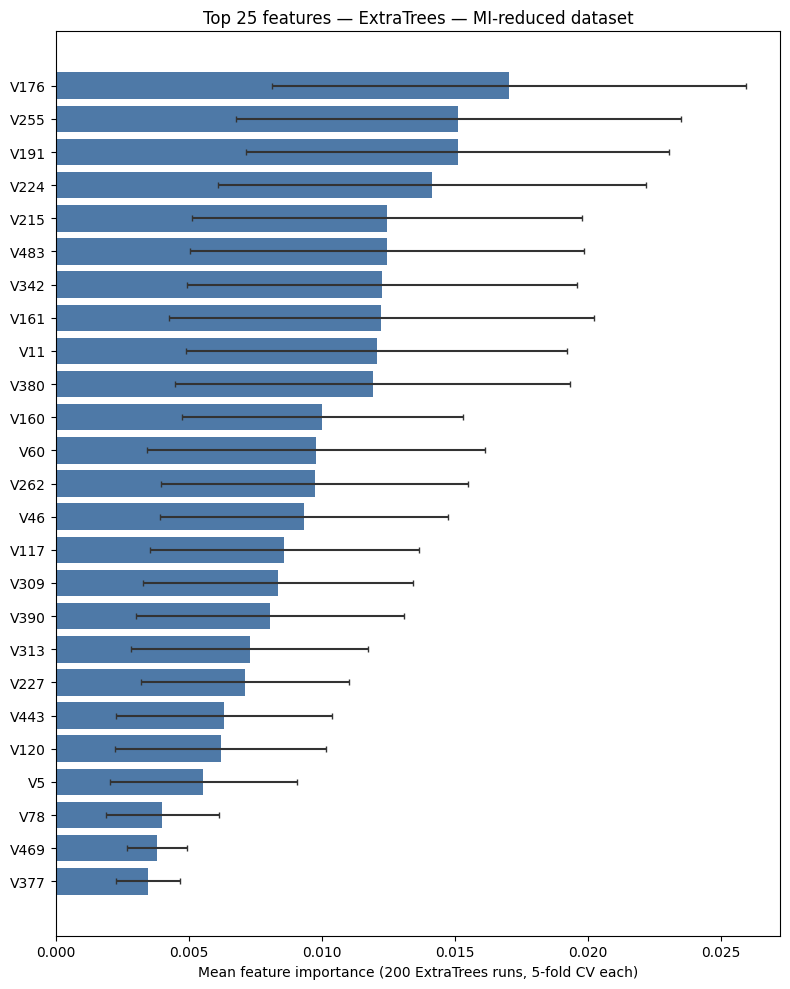

In [4]:
extra_scores, extra_importance_long, extra_summary = run_model_study('extra', N_RUNS)

### 3. Assess the feature importances using different configurations of LightGBM

=== LightGBM (lgbm) — 200 runs, 5-fold CV ===
Completed 1/200 runs
Completed 2/200 runs
Completed 3/200 runs
Completed 4/200 runs
Completed 5/200 runs
Completed 6/200 runs
Completed 7/200 runs
Completed 8/200 runs
Completed 9/200 runs
Completed 10/200 runs
Completed 11/200 runs
Completed 12/200 runs
Completed 13/200 runs
Completed 14/200 runs
Completed 15/200 runs
Completed 16/200 runs
Completed 17/200 runs
Completed 18/200 runs
Completed 19/200 runs
Completed 20/200 runs
Completed 21/200 runs
Completed 22/200 runs
Completed 23/200 runs
Completed 24/200 runs
Completed 25/200 runs
Completed 26/200 runs
Completed 27/200 runs
Completed 28/200 runs
Completed 29/200 runs
Completed 30/200 runs
Completed 31/200 runs
Completed 32/200 runs
Completed 33/200 runs
Completed 34/200 runs
Completed 35/200 runs
Completed 36/200 runs
Completed 37/200 runs
Completed 38/200 runs
Completed 39/200 runs
Completed 40/200 runs
Completed 41/200 runs
Completed 42/200 runs
Completed 43/200 runs
Completed 44/200 

,run_id,random_seed,model_type,config_type,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,...,tp_std,fp_mean,fp_std,param_n_estimators,param_learning_rate,param_num_leaves,param_min_child_samples,param_colsample_bytree,param_reg_alpha,param_reg_lambda
0,0,0,lgbm,default,0.6648,0.014358,0.662901,0.016791,0.665194,0.014532,...,7.211103,168.6,12.970736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,lgbm,random,0.6496,0.012816,0.647251,0.011200,0.649920,0.023806,...,11.859174,176.2,6.615134,137.0,0.179578,92.0,19.0,0.651166,0.146756,0.684677
2,2,2,lgbm,random,0.6616,0.010744,0.658687,0.013152,0.664799,0.008984,...,4.166533,171.6,10.111380,268.0,0.057762,92.0,32.0,0.973865,0.484749,1.141073
3,3,3,lgbm,random,0.6706,0.007710,0.671871,0.011737,0.661566,0.012547,...,6.493073,161.0,10.601887,252.0,0.136222,76.0,18.0,0.755414,0.892947,2.292586
4,4,4,lgbm,random,0.6636,0.007144,0.662500,0.009824,0.661188,0.018353,...,8.876936,167.8,10.186265,222.0,0.165093,89.0,11.0,0.927810,0.609036,1.695112



Top 20 features by mean importance:


,feature_name,importance_mean,importance_std,rank
0,V380,140.559,52.795547,1
1,V215,140.313,52.508398,2
2,V342,137.365,51.191509,3
3,V255,133.186,51.517204,4
4,V191,130.279,49.861077,5
5,V176,129.414,50.501002,6
6,V160,117.529,46.779083,7
7,V117,114.635,43.916172,8
8,V390,101.883,40.692890,9
9,V227,99.472,37.733480,10


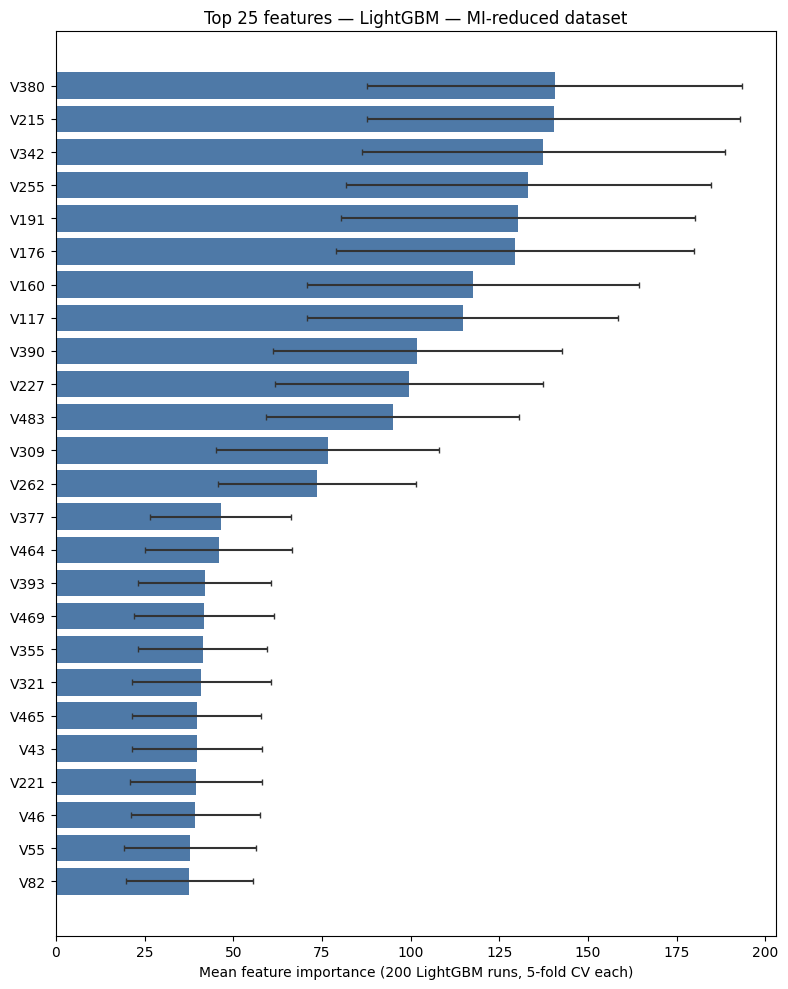

In [5]:
lgbm_scores, lgbm_importance_long, lgbm_summary = run_model_study('lgbm', N_RUNS)

### 4. Assess the feature importances using different configurations of XGBoost

=== XGBoost (xgb) — 200 runs, 5-fold CV ===
Completed 1/200 runs
Completed 2/200 runs
Completed 3/200 runs
Completed 4/200 runs
Completed 5/200 runs
Completed 6/200 runs
Completed 7/200 runs
Completed 8/200 runs
Completed 9/200 runs
Completed 10/200 runs
Completed 11/200 runs
Completed 12/200 runs
Completed 13/200 runs
Completed 14/200 runs
Completed 15/200 runs
Completed 16/200 runs
Completed 17/200 runs
Completed 18/200 runs
Completed 19/200 runs
Completed 20/200 runs
Completed 21/200 runs
Completed 22/200 runs
Completed 23/200 runs
Completed 24/200 runs
Completed 25/200 runs
Completed 26/200 runs
Completed 27/200 runs
Completed 28/200 runs
Completed 29/200 runs
Completed 30/200 runs
Completed 31/200 runs
Completed 32/200 runs
Completed 33/200 runs
Completed 34/200 runs
Completed 35/200 runs
Completed 36/200 runs
Completed 37/200 runs
Completed 38/200 runs
Completed 39/200 runs
Completed 40/200 runs
Completed 41/200 runs
Completed 42/200 runs
Completed 43/200 runs
Completed 44/200 ru

,run_id,random_seed,model_type,config_type,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,...,fp_mean,fp_std,param_n_estimators,param_learning_rate,param_max_depth,param_subsample,param_colsample_bytree,param_min_child_weight,param_reg_alpha,param_reg_lambda
0,0,0,xgb,default,0.6460,0.014170,0.649393,0.017521,0.628208,0.017989,...,169.0,12.083046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,xgb,random,0.6354,0.011943,0.640555,0.014894,0.609726,0.006925,...,170.4,9.286549,137.0,0.179578,3.0,0.500057,0.651166,1.0,0.092339,0.872520
2,2,2,xgb,random,0.6792,0.012480,0.688731,0.014474,0.648721,0.013225,...,146.0,8.876936,268.0,0.057762,3.0,0.774831,0.717661,9.0,0.320536,0.808853
3,3,3,xgb,random,0.6422,0.004069,0.645575,0.004137,0.622993,0.003701,...,170.2,2.481935,252.0,0.136222,3.0,0.560664,0.784656,4.0,0.896293,0.751171
4,4,4,xgb,random,0.6588,0.007756,0.663022,0.009404,0.639470,0.011318,...,161.8,6.939741,222.0,0.165093,8.0,0.986342,0.857408,3.0,0.597556,0.782928



Top 20 features by mean importance:


,feature_name,importance_mean,importance_std,rank
0,V11,0.005500,0.001365,1
1,V160,0.005154,0.000606,2
2,V255,0.005115,0.000592,3
3,V176,0.005093,0.000565,4
4,V191,0.004885,0.000546,5
5,V224,0.004569,0.001089,6
6,V215,0.004384,0.000482,7
7,V380,0.004313,0.000442,8
8,V342,0.004161,0.000413,9
9,V117,0.004141,0.000404,10


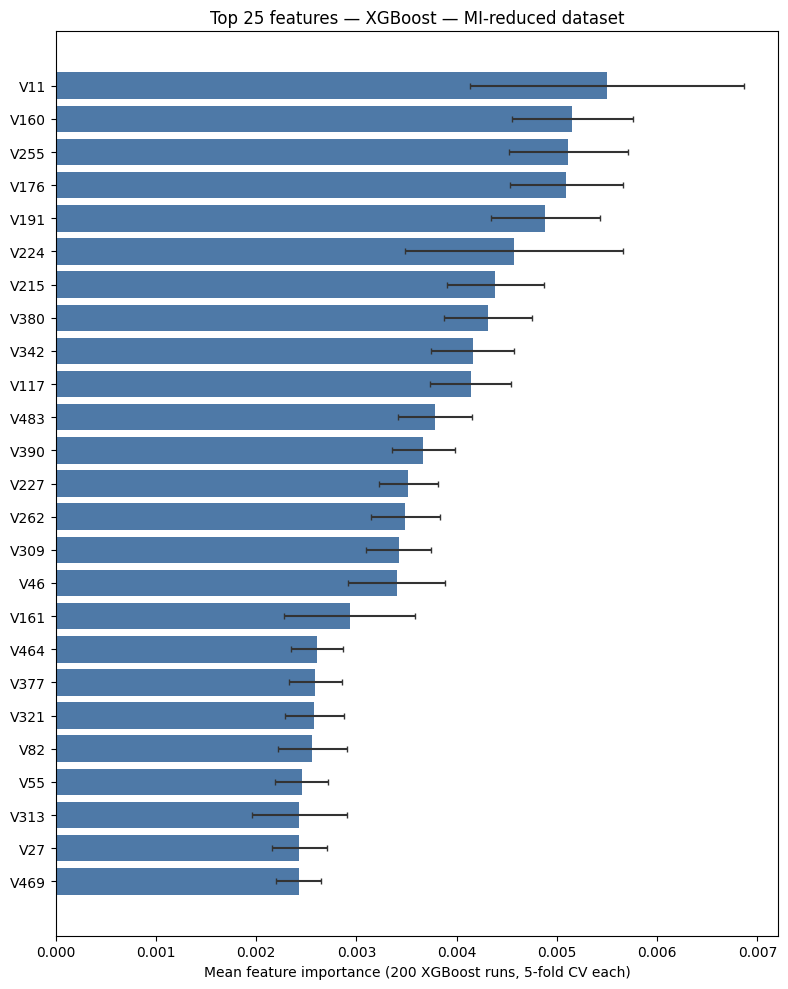

In [6]:
xgb_scores, xgb_importance_long, xgb_summary = run_model_study('xgb', N_RUNS)

### Aggregation over all these 4 tree based models

In [7]:
MODEL_TYPES = ['rf', 'extra', 'lgbm', 'xgb']

def normalize_summary(summary):
    s = summary.copy()
    total = s['importance_mean'].sum()
    s['importance_mean'] = s['importance_mean'] / total
    s['importance_std'] = s['importance_std'] / total
    return s

summaries = {
    'rf': normalize_summary(rf_summary),
    'extra': normalize_summary(extra_summary),
    'lgbm': normalize_summary(lgbm_summary),
    'xgb': normalize_summary(xgb_summary),
}

parts = []
for mt in MODEL_TYPES:
    s = summaries[mt][['feature_name', 'importance_mean', 'importance_std']].copy()
    s = s.rename(columns={
        'importance_mean': f'{mt}_importance_mean',
        'importance_std': f'{mt}_importance_std',
    })
    parts.append(s)

merged = parts[0]
for part in parts[1:]:
    merged = merged.merge(part, on='feature_name', how='outer')

mean_cols = [f'{mt}_importance_mean' for mt in MODEL_TYPES]
std_cols = [f'{mt}_importance_std' for mt in MODEL_TYPES]

merged['importance_mean'] = merged[mean_cols].mean(axis=1)
merged['importance_std_mean'] = merged[std_cols].mean(axis=1)

aggregate_summary = (
    merged[['feature_name', 'importance_mean', 'importance_std_mean'] + mean_cols + std_cols]
    .sort_values('importance_mean', ascending=False)
    .reset_index(drop=True)
)
aggregate_summary['rank'] = np.arange(1, len(aggregate_summary) + 1)

print(f'Aggregated over {len(MODEL_TYPES)} models, {len(aggregate_summary)} features')
display(aggregate_summary.head(25))


Aggregated over 4 models, 493 features


,feature_name,importance_mean,importance_std_mean,rf_importance_mean,extra_importance_mean,lgbm_importance_mean,xgb_importance_mean,rf_importance_std,extra_importance_std,lgbm_importance_std,xgb_importance_std,rank
0,V176,0.013638,0.005221,0.022652,0.017028,0.009781,0.005093,0.007609,0.008895,0.003817,0.000565,1
1,V255,0.013024,0.004960,0.021787,0.015128,0.010066,0.005115,0.006997,0.008359,0.003894,0.000592,2
2,V191,0.012958,0.004980,0.021992,0.015108,0.009846,0.004885,0.007658,0.007949,0.003768,0.000546,3
3,V160,0.010624,0.003875,0.018447,0.010012,0.008882,0.005154,0.006071,0.005287,0.003535,0.000606,4
4,V215,0.010427,0.003986,0.014273,0.012447,0.010604,0.004384,0.004171,0.007323,0.003968,0.000482,5
5,V380,0.010238,0.004066,0.014108,0.011908,0.010623,0.004313,0.004408,0.007424,0.003990,0.000442,6
6,V342,0.010159,0.003872,0.013829,0.012262,0.010382,0.004161,0.003865,0.007340,0.003869,0.000413,7
7,V483,0.009226,0.003645,0.013508,0.012437,0.007175,0.003784,0.004101,0.007406,0.002700,0.000373,8
8,V224,0.009058,0.004203,0.015395,0.014139,0.002126,0.004569,0.006682,0.008034,0.001006,0.001089,9
9,V11,0.008136,0.003850,0.013077,0.012053,0.001913,0.005500,0.005943,0.007150,0.000939,0.001365,10


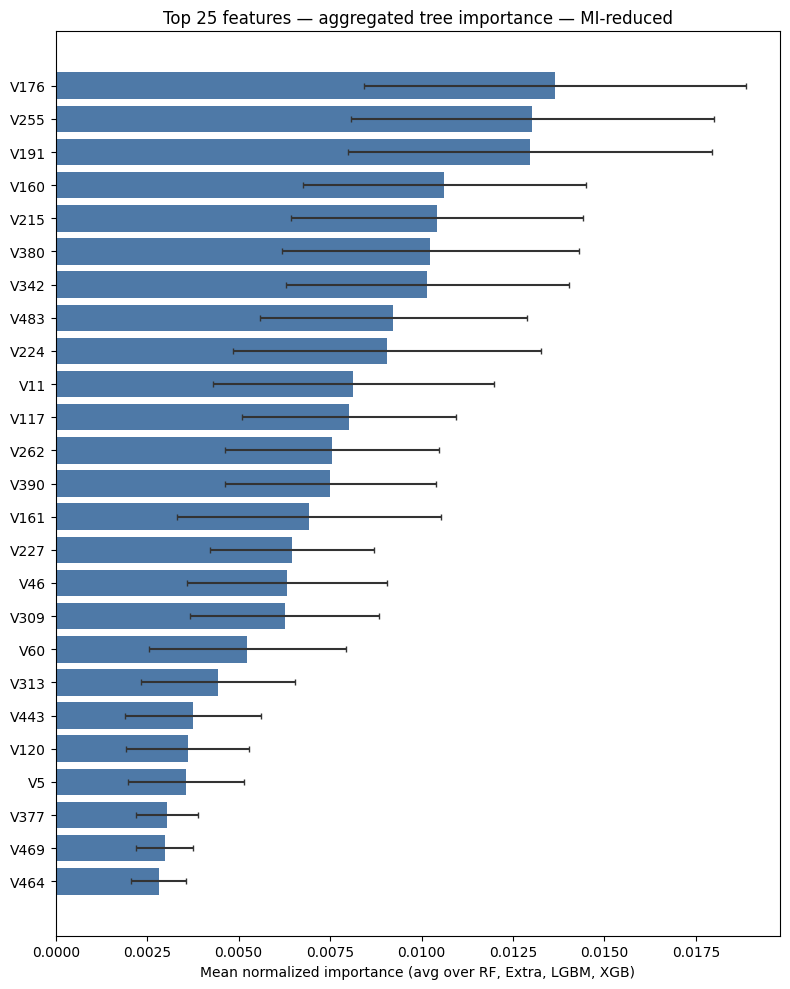

In [8]:
top_n = 25

plot_df = aggregate_summary.head(top_n).iloc[::-1]  
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(
    plot_df['feature_name'],
    plot_df['importance_mean'],
    xerr=plot_df['importance_std_mean'],
    color='#4e79a7',
    ecolor='#333333',
    capsize=2,
)
ax.set_xlabel('Mean normalized importance (avg over RF, Extra, LGBM, XGB)')
ax.set_title(f'Top {top_n} features — aggregated tree importance — MI-reduced')
plt.tight_layout()
plt.show()